In [1]:
import os
import sys
if '../' not in sys.path:
    sys.path.append('../')
    
import numpy as np
import scipy.special as sps
from mpmath import fp as fp
import vegas
from functools import partial

from scipy.integrate import quad

import matplotlib.pyplot as plt

# Compute plasma mass of photon

/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/plasma.py:8: RuntimeWarning: overflow encountered in exp
  return np.sqrt(z**2 - x**2)/(np.exp(z)+1)


(0.001, 100000.0)

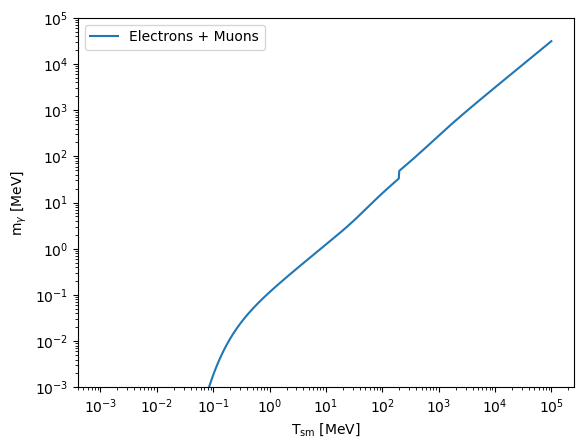

In [2]:
from mcp_boltzmann.plasma import m_gam_2

T_sm_grid = np.geomspace(1e-3, 1e5, 1000)
mg2 = m_gam_2(T_sm_grid)
mgam_grid = np.sqrt(mg2)

plt.plot(T_sm_grid, mgam_grid, label='Electrons + Muons')
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'T$_{\rm sm}$ [MeV]')
plt.ylabel(r'm$_{\gamma}$ [MeV]')
plt.ylim(1e-3, 1e5)

In [3]:
from scipy.interpolate import interp1d

mgam_interp = interp1d(T_sm_grid, mgam_grid, bounds_error=False, fill_value=(0, mgam_grid[-1]))

def mgamma_thermal(T_sm, T_ds):
    return mgam_interp(T_sm)

# Elastic Scattering Collision Integral

## Calculation of quantum statistics corrections to MB collision integrals

In [4]:
from mcp_boltzmann.elastic_scattering import ElasticCollisionIntegral

test_proc_MB = ElasticCollisionIntegral(0, 1, 0)
test_proc_FD = ElasticCollisionIntegral(0, 1, 0, 1, 1)
test_proc_BE = ElasticCollisionIntegral(0, 1, 0, -1, -1)

test_proc_MB.matrix_element_nml['c002'] = 1.0
test_proc_FD.matrix_element_nml['c002'] = 1.0
test_proc_BE.matrix_element_nml['c002'] = 1.0

In [5]:
T_a_range = np.geomspace(1e-1, 1e2)
T_b_range = 0.3*T_a_range

In [6]:
MB_res = np.zeros(len(T_a_range))
FD_res = np.zeros(len(T_a_range))
BE_res = np.zeros(len(T_a_range))

for (i, T_a) in enumerate(T_a_range):
    T_b = T_b_range[i]
    MB_res[i] = test_proc_MB.compute_MB(T_a, T_b)[0]
    FD_res[i] = test_proc_FD.compute_QS(T_a, T_b)[0]
    BE_res[i] = test_proc_BE.compute_QS(T_a, T_b)[0]

/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/elastic_scattering.py:139: RuntimeWarning: overflow encountered in expm1
  -np.power(np.expm1(p0/T_b), -1)*np.power(-np.expm1(-p0/T_a), -1)


In [7]:
m_b = 10
m_e = 0.511
m_mu = 105
m_tau = 1776
m_phi = 0
MCP_model_coulomb = ElasticCollisionIntegral(m_e, m_b, mgamma_thermal, zeta_a=1, zeta_b=1)
MCP_model_coulomb.matrix_element_nml['c222'] = 0.75
MCP_model_coulomb.matrix_element_nml['c002'] = 0.75
MCP_model_coulomb.matrix_element_nml['c202'] = -0.25
MCP_model_coulomb.matrix_element_nml['c022'] = -0.25
MCP_model_coulomb.matrix_element_nml['c001'] = m_b**2 + m_e**2
MCP_model_coulomb.matrix_element_nml['c201'] = m_b**2
MCP_model_coulomb.matrix_element_nml['c021'] = m_e**2
MCP_model_coulomb.matrix_element_nml['c000'] = 4*m_e**2*m_b**2

In [8]:
MCP_model_coulomb_mu = ElasticCollisionIntegral(m_mu, m_b, mgamma_thermal, zeta_a=1, zeta_b=1)
MCP_model_coulomb_mu.matrix_element_nml['c222'] = 0.75
MCP_model_coulomb_mu.matrix_element_nml['c002'] = 0.75
MCP_model_coulomb_mu.matrix_element_nml['c202'] = -0.25
MCP_model_coulomb_mu.matrix_element_nml['c022'] = -0.25
MCP_model_coulomb_mu.matrix_element_nml['c001'] = m_b**2 + m_mu**2
MCP_model_coulomb_mu.matrix_element_nml['c201'] = m_b**2
MCP_model_coulomb_mu.matrix_element_nml['c021'] = m_mu**2
MCP_model_coulomb_mu.matrix_element_nml['c000'] = 4*m_mu**2*m_b**2

In [9]:
MCP_model_coulomb_tau = ElasticCollisionIntegral(m_tau, m_b, mgamma_thermal, zeta_a=1, zeta_b=1)
MCP_model_coulomb_tau.matrix_element_nml['c222'] = 0.75
MCP_model_coulomb_tau.matrix_element_nml['c002'] = 0.75
MCP_model_coulomb_tau.matrix_element_nml['c202'] = -0.25
MCP_model_coulomb_tau.matrix_element_nml['c022'] = -0.25
MCP_model_coulomb_tau.matrix_element_nml['c001'] = m_b**2 + m_tau**2
MCP_model_coulomb_tau.matrix_element_nml['c201'] = m_b**2
MCP_model_coulomb_tau.matrix_element_nml['c021'] = m_tau**2
MCP_model_coulomb_tau.matrix_element_nml['c000'] = 4*m_tau**2*m_b**2

In [10]:
#assuming massless quarks
MCP_model_coulomb_lq = ElasticCollisionIntegral(0.0, m_b, mgamma_thermal, zeta_a=1, zeta_b=1)
MCP_model_coulomb_lq.matrix_element_nml['c222'] = 0.75
MCP_model_coulomb_lq.matrix_element_nml['c002'] = 0.75
MCP_model_coulomb_lq.matrix_element_nml['c202'] = -0.25
MCP_model_coulomb_lq.matrix_element_nml['c022'] = -0.25
MCP_model_coulomb_lq.matrix_element_nml['c001'] = m_b**2 
MCP_model_coulomb_lq.matrix_element_nml['c201'] = m_b**2
MCP_model_coulomb_lq.matrix_element_nml['c021'] = 0
MCP_model_coulomb_lq.matrix_element_nml['c000'] = 0

m_s = 95
MCP_model_coulomb_strange = ElasticCollisionIntegral(m_s, m_b, mgamma_thermal, zeta_a=1, zeta_b=1)
MCP_model_coulomb_strange.matrix_element_nml['c222'] = 0.75
MCP_model_coulomb_strange.matrix_element_nml['c002'] = 0.75
MCP_model_coulomb_strange.matrix_element_nml['c202'] = -0.25
MCP_model_coulomb_strange.matrix_element_nml['c022'] = -0.25
MCP_model_coulomb_strange.matrix_element_nml['c001'] = m_b**2 + m_s**2
MCP_model_coulomb_strange.matrix_element_nml['c201'] = m_b**2
MCP_model_coulomb_strange.matrix_element_nml['c021'] = m_s**2
MCP_model_coulomb_strange.matrix_element_nml['c000'] = 4*m_s**2*m_b**2

m_c = 1270
MCP_model_coulomb_charm = ElasticCollisionIntegral(m_c, m_b, mgamma_thermal, zeta_a=1, zeta_b=1)
MCP_model_coulomb_charm.matrix_element_nml['c222'] = 0.75
MCP_model_coulomb_charm.matrix_element_nml['c002'] = 0.75
MCP_model_coulomb_charm.matrix_element_nml['c202'] = -0.25
MCP_model_coulomb_charm.matrix_element_nml['c022'] = -0.25
MCP_model_coulomb_charm.matrix_element_nml['c001'] = m_b**2 + m_c**2
MCP_model_coulomb_charm.matrix_element_nml['c201'] = m_b**2
MCP_model_coulomb_charm.matrix_element_nml['c021'] = m_c**2
MCP_model_coulomb_charm.matrix_element_nml['c000'] = 4*m_c**2*m_b**2

In [11]:
T_a_over_m_b_range = np.geomspace(1e-1, 1e2, 20)

mcp_res = np.zeros(len(T_a_over_m_b_range))
mcp_res_MB = np.zeros(len(T_a_over_m_b_range))

for (i, T_over_m) in enumerate(T_a_over_m_b_range):
    T_a = T_over_m*m_b
    T_b = 0.3*T_a

    mcp_res_MB[i] = MCP_model_coulomb.compute_MB(T_a, T_b, n_strat=[3]+[3], neval=1e4)[0]
    mcp_res[i] = MCP_model_coulomb.compute_QS(T_a, T_b, n_strat=[3]+[3], neval=1e4)[0]

In [12]:
#load up some CSVs of 2206.13530 Figure 9 to compare
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

shelton_f9_FD = load_csv('../input/fig/2206.13530_fig9_right_Fermi-Dirac.csv')
shelton_f9_BE = load_csv('../input/fig/2206.13530_fig9_right_Bose-Einstein.csv')
shelton_f9_MCP = load_csv('../input/fig/2206.13530_fig9_right_MCP Model.csv')

### Compare to the right panel of Figure 9 of 2206.13530

(0.1, 100.0)

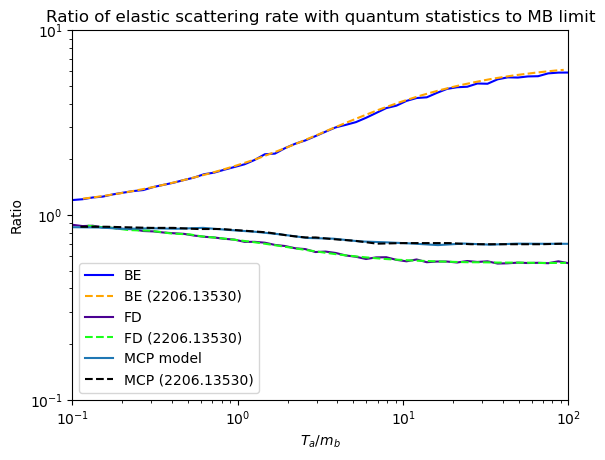

In [13]:
plt.plot(T_a_range, BE_res/MB_res, color='blue', label='BE')
plt.plot(*shelton_f9_BE, color='orange', linestyle='dashed',label='BE (2206.13530)')

plt.plot(T_a_range, FD_res/MB_res, color='#4B0092', label='FD')
plt.plot(*shelton_f9_FD, linestyle='dashed', color='#1AFF1A',label='FD (2206.13530)')

plt.plot(T_a_over_m_b_range, mcp_res/mcp_res_MB, label='MCP model')
plt.plot(*shelton_f9_MCP, linestyle='dashed', color='black',label='MCP (2206.13530)')

plt.yscale('log')
plt.xscale('log')

plt.xlabel(r'$T_a/m_b$')
plt.ylabel('Ratio')
plt.title('Ratio of elastic scattering rate with quantum statistics to MB limit')

plt.legend()

plt.ylim(1e-1, 10)
plt.xlim(1e-1, 1e2)

### Compare to the left panel of Figure 8 of 2206.13530

In [14]:
#model params
Q = 1e-9
e = np.sqrt(4*np.pi/137)

q_u = 2/3
q_d = -1/3
q_s = -1/3
q_c = 2/3

#factor to scale the coeeficients by
pref = 16*np.pi*e**4*Q**2
pref_lq = 16*np.pi*e**4*Q**2*(q_u**2 + q_d**2)
pref_strange = 16*np.pi*e**4*Q**2*(q_s**2)
pref_charm = 16*np.pi*e**4*Q**2*(q_c**2)

In [15]:
T_range = np.geomspace(1, 1e3, 100)
T_ratio = 0.35
res = np.zeros(len(T_range))
res_mu = np.zeros(len(T_range))
res_tau = np.zeros(len(T_range))
res_lq = np.zeros(len(T_range))
res_strange = np.zeros(len(T_range))
res_charm = np.zeros(len(T_range))

for (i, T) in enumerate(T_range):
    res[i] = MCP_model_coulomb.compute_QS(T, T_ratio*T)[0]
    res_mu[i] = MCP_model_coulomb_mu.compute_QS(T, T_ratio*T)[0]
    res_tau[i] = MCP_model_coulomb_tau.compute_QS(T, T_ratio*T)[0]
    res_lq[i] = MCP_model_coulomb_lq.compute_QS(T, T_ratio*T)[0]
    res_strange[i] = MCP_model_coulomb_strange.compute_QS(T, T_ratio*T)[0]
    res_charm[i] = MCP_model_coulomb_charm.compute_QS(T, T_ratio*T)[0]
    

/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/elastic_scattering.py:138: RuntimeWarning: overflow encountered in expm1
  +np.power(np.expm1(p0/T_a), -1)*np.power(-np.expm1(-p0/T_b), -1)


In [16]:
shelton_f8_035 = load_csv('../input/fig/2206.13530_fig8_left_035.csv')
shelton_f8_080 = load_csv('../input/fig/Ths_08Tsm.csv')

(1e-28, 2e-24)

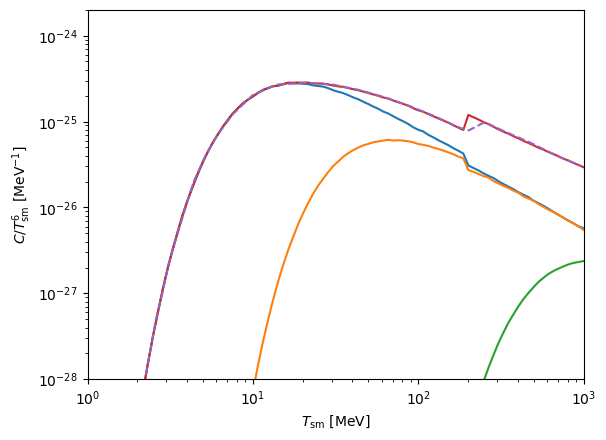

In [76]:
LQCD = 200
qed = 4*pref*(res+res_mu+res_tau)/T_range**6
qcd = 3*np.heaviside(T_range - LQCD, 0)*(
    4*pref_lq*(res_lq)/T_range**6 
  + 4*pref_strange*res_strange/T_range**6 
  + 4*pref_charm*res_charm/T_range**6
)

plt.plot(T_range, 4*pref*(res)/T_range**6)
plt.plot(T_range, 4*pref*(res_mu)/T_range**6)
plt.plot(T_range, 4*pref*(res_tau)/T_range**6)

# plt.plot(T_range, qcd, linestyle='none', marker='o')
plt.plot(T_range, qed + qcd)
plt.plot(*shelton_f8_035, linestyle='dashed')
# plt.plot(*shelton_f8_080, linestyle='dashed')
plt.yscale('log')
plt.xscale('log')

plt.xlabel(r'$T_{\rm sm}$ [MeV]')
plt.ylabel(r'$C/T^6_{\rm sm}$ [MeV$^{-1}$]')

plt.xlim(1, 1e3)
plt.ylim(1e-28, 2e-24)

In [31]:
from mcp_boltzmann.elastic_scattering import load_tabulated_rate
from scipy.interpolate import LinearNDInterpolator

In [41]:
foo = np.load('../output/rates/coulomb/mcp_coulomb_rate_m_10.0_Q_1.npz')

FileNotFoundError: [Errno 2] No such file or directory: '../output/rates/coulomb/mcp_coulomb_rate_m_10.0_Q_1.npz'

In [32]:
def load_tabulated_rate(path):
    with np.load(path) as rate_file:
        return LinearNDInterpolator(rate_file['temp_grid'], rate_file['rate'], fill_value=0.0)

In [77]:
tab_rate = load_tabulated_rate('../output/rates/coulomb/mcp_coulomb_rate_m_10.0_Q_1.npz')

(1e-28, 2e-24)

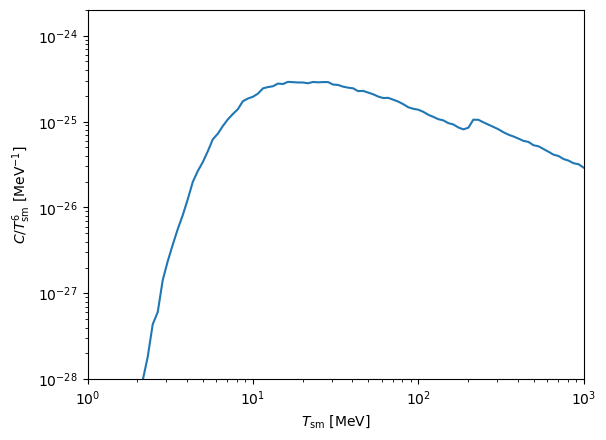

In [78]:
plt.plot(T_range, Q**2*tab_rate(T_range, T_ratio*T_range)/T_range**6)

plt.yscale('log')
plt.xscale('log')

plt.xlabel(r'$T_{\rm sm}$ [MeV]')
plt.ylabel(r'$C/T^6_{\rm sm}$ [MeV$^{-1}$]')

plt.xlim(1, 1e3)
plt.ylim(1e-28, 2e-24)

In [40]:
tab_rate(T_range, T_ratio*T_range)

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       9.10143778e-07, 1.91990540e-06, 3.00263969e-06, 4.16362017e-06,
       5.40850150e-06, 6.74334693e-06, 8.17465794e-06, 9.72217127e-06,
       1.13815191e-05, 2.50570565e-05, 6.12056651e-05, 3.84270677e-04,
       7.44795999e-04, 1.13137548e-03, 1.54589200e-03, 1.99036446e-03,
       2.46695772e-03, 2.97799305e-03, 7.50189343e-03, 1.23527235e-02,
       1.75541096e-02, 2.31313855e-02, 5.56727170e-02, 9.18842501e-02,
       1.30712690e-01, 1.72347154e-01, 2.16990424e-01, 2.64859940e-01,
       3.16188852e-01, 8.01818956e-01, 1.32254420e+00, 1.88090081e+00,
       2.47960830e+00, 4.83358319e+00, 7.44265971e+00, 1.02402869e+01,
       1.32400909e+01, 1.64566824e+01, 1.99057280e+01, 2.36040266e+01,
      

In [42]:
np.geomspace(1.0, 1000, 10)

array([   1.        ,    2.15443469,    4.64158883,   10.        ,
         21.5443469 ,   46.41588834,  100.        ,  215.443469  ,
        464.15888336, 1000.        ])

In [43]:
10*0.35

3.5

In [61]:
Q**2*tab_rate(21.5443469, 10.0)

5.257137416540346e-19

In [65]:
4*pref*MCP_model_coulomb.compute_QS(21.5443469, 10.0, neval=1e3)[0]

5.0425369882392834e-17

In [70]:
alpha = 1.0/137.0
e = np.sqrt(4/alpha/np.pi)

In [71]:
e

13.207339536360731

In [72]:
np.sqrt(4*alpha*np.pi)

0.30286190409413793

In [ ]:
np.s